# Concordant significant genes vs Pearson correlation

This notebook recreates the concordant-genes/correlation figure using significant genes only, filtered by raw p value rather than FDR-adjusted p value. It writes one figure per cell type.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
from pathlib import Path
from scipy.stats import pearsonr

try:
    from cellseg_benchmark._constants import method_colors
except ImportError:
    method_colors = {}


In [2]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})


In [3]:
mount_root = Path("/Users/mira/Documents/Uni/cellseg_benchmarking/mounts/dss")


jin_dea_path = mount_root / "dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/Jin_Nature_2025_full_de_results.csv"
analysis_root = mount_root / "dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging"
dea_filename = "aging-by-celltype_MAST_2k_MAST_m18vsm3.xlsx"
out_path = Path("/Users/mira/Documents/Uni/cellseg_benchmarking/out")
out_path.mkdir(parents=True, exist_ok=True)

alpha = 0.05
cell_type_map = {
    "ECs": "Endo NN_1",
    "Microglia": "Microglia NN_1",
    "OPCs": "OPC NN_1",
    "Pericytes": "Peri NN_1",
    "SMCs": "SMC NN_1",
}
cell_types_to_plot = list(cell_type_map)

exclude_methods = {"SIS_DAPI_total_mrna", "Watershed_Merlin"}
figure_formats = ("png", "pdf", "svg")


In [11]:
raw_pvalue_columns = (
    "pval",
    "p_val",
    "pvalue",
    "p_value",
    "p.value",
    "p.val",
    "P.Value",
    "p",
    "Pr(>|z|)",
    "Pr(>Chisq)",
    "PValue"
)

def find_raw_pvalue_column(df, table_name):
    for column in raw_pvalue_columns:
        if column in df.columns:
            return column
    raise ValueError(
        f"No raw p-value column found in {table_name}. "
        f"Looked for: {', '.join(raw_pvalue_columns)}"
    )

def significant_rows(df, table_name, alpha=0.05):
    pvalue_column = find_raw_pvalue_column(df, table_name)
    return df[df[pvalue_column] < alpha].copy()

def safe_pearsonr(x, y):
    if len(x) < 2 or x.nunique() < 2 or y.nunique() < 2:
        return np.nan, np.nan
    return pearsonr(x, y)


In [5]:
method_colors["Proseg_3D_Cellpose_1_DAPI_PolyT"] = "#d1c9b4"
method_colors["Proseg_3D_Cellpose_1_DAPI_Transcripts"] = "#d6c9a9"

def get_methods():
    methods = [
        path.name
        for path in analysis_root.iterdir()
        if path.is_dir()
        and not path.name.startswith("Negative")
        and path.name not in exclude_methods
    ]
    return sorted(methods)

def get_method_palette(methods):
    fallback = dict(zip(methods, sns.color_palette("tab20", n_colors=len(methods))))
    return {method: method_colors.get(method, fallback[method]) for method in methods}

methods = get_methods()
methods


['Baysor_2D_Cellpose_1_DAPI_PolyT_0.2',
 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2',
 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8',
 'Baysor_2D_Cellpose_1_nuclei_model_1.0',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2',
 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.2',
 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8',
 'Cellpose_1_DAPI_PolyT',
 'Cellpose_1_DAPI_Transcripts',
 'Cellpose_1_Merlin',
 'Cellpose_1_nuclei_model',
 'Cellpose_2_DAPI_PolyT',
 'Cellpose_2_DAPI_Transcripts',
 'Proseg_3D_Cellpose_1_DAPI_PolyT',
 'Proseg_3D_Cellpose_1_DAPI_Transcripts',
 'Proseg_3D_Cellpose_1_nuclei_model',
 'Proseg_3D_Cellpose_2_DAPI_PolyT',
 'Proseg_3D_Cellpose_2_DAPI_Transcripts',
 'Proseg_3D_vpt3D_DAPI_PolyT',
 'Proseg_3D_vpt3D_DAPI_PolyT_nuclei',
 'Proseg_3D_vpt3D_DAPI_nuclei',
 'vpt_2D_DAPI_PolyT',
 'vpt_2D_DAPI_PolyT_nuclei',
 'vpt_2D_DAPI_nuclei',
 'vpt_3D_DAPI_PolyT',
 'vpt_3D_DAPI_PolyT_nuclei',
 'vpt_3D_DAPI_nuclei']

In [6]:
jin_dea = pd.read_csv(jin_dea_path)
jin_dea = jin_dea[jin_dea["subclass"].isin(cell_type_map.values())].copy()


In [7]:
def calculate_method_result(method, cell_type):
    dea_path = analysis_root / method / "dea" / dea_filename
    dea_by_cell_type = pd.read_excel(dea_path, sheet_name=None)

    dea_sub = significant_rows(dea_by_cell_type[cell_type], f"{method} {cell_type} DEA", alpha=alpha)
    jin_sub = jin_dea[jin_dea["subclass"] == cell_type_map[cell_type]].copy()
    jin_sub = significant_rows(jin_sub, f"Jin {cell_type} DEA", alpha=alpha)

    common_gene_order = [gene for gene in dea_sub["gene"] if gene in set(jin_sub["primerid"])]
    dea_sub = dea_sub.set_index("gene").loc[common_gene_order]
    jin_sub = jin_sub.set_index("primerid").loc[common_gene_order]

    corr, pval = safe_pearsonr(dea_sub["log2FC"], jin_sub["coef"])
    matching = np.sign(dea_sub["log2FC"]) == np.sign(jin_sub["coef"])
    n_common = len(common_gene_order)
    n_matching = int(matching.sum())

    return {
        "method": method,
        "pearson correlation": corr,
        "correlation pvalue": pval,
        "# significant common genes": n_common,
        "# matching genes": n_matching,
        "% matching genes": (100 * n_matching / n_common) if n_common else np.nan,
    }

def calculate_cell_type_results(cell_type, methods=methods):
    return pd.DataFrame(calculate_method_result(method, cell_type) for method in methods)


In [ ]:
def value_to_size(value, vmin, vmax, min_size=50, max_size=150):
    if vmax <= vmin:
        return (min_size + max_size) / 2
    fraction = (value - vmin) / (vmax - vmin)
    return min_size + fraction * (max_size - min_size)

def size_legend_handles(size_data, min_size=50, max_size=150, n_breaks=5):
    size_data = pd.Series(size_data).dropna()
    if size_data.empty:
        return [], []
    breaks = np.linspace(size_data.min(), size_data.max(), n_breaks)
    breaks = sorted({int(round(value)) for value in breaks})
    handles = [
        mlines.Line2D(
            [],
            [],
            linestyle="",
            marker="o",
            markersize=value_to_size(value, size_data.min(), size_data.max(), min_size, max_size) ** 0.5,
            color="k",
        )
        for value in breaks
    ]
    return handles, [str(value) for value in breaks]

def plot_cell_type_results(cell_type, methods=methods):
    res_df = calculate_cell_type_results(cell_type, methods=methods)
    res_df.to_excel(out_path / f"DEA_corr_raw_pvalue_significant_genes_{cell_type}.xlsx", index=False)

    min_size, max_size = 50, 150
    fig, ax = plt.subplots(figsize=(8, 11))
    sns.scatterplot(
        data=res_df,
        x="pearson correlation",
        y="% matching genes",
        hue="method",
        palette=get_method_palette(res_df["method"].tolist()),
        size="# significant common genes",
        sizes=(min_size, max_size),
        ax=ax,
    )

    ax.set_title(cell_type)
    ax.set_xlabel("pearson correlation")
    ax.set_ylabel("% matching genes")
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 10))

    handles_all, labels_all = ax.get_legend_handles_labels()
    method_handles = []
    method_labels = []
    for handle, label in zip(handles_all, labels_all):
        if label in set(res_df["method"]):
            method_handles.append(handle)
            method_labels.append(label)

    if ax.legend_ is not None:
        ax.legend_.remove()

    method_legend = ax.legend(
        method_handles,
        method_labels,
        title="method",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )

    size_handles, size_labels = size_legend_handles(
        res_df["# significant common genes"],
        min_size=min_size,
        max_size=max_size,
    )
    if size_handles:
        size_legend = ax.legend(
            size_handles,
            size_labels,
            title="# significant common genes",
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
        )
        ax.add_artist(method_legend)

    fig.tight_layout()
    for figure_format in figure_formats:
        fig.savefig(out_path / f"DEA_corr_raw_pvalue_significant_genes_{cell_type}.{figure_format}")
    return res_df, fig, ax


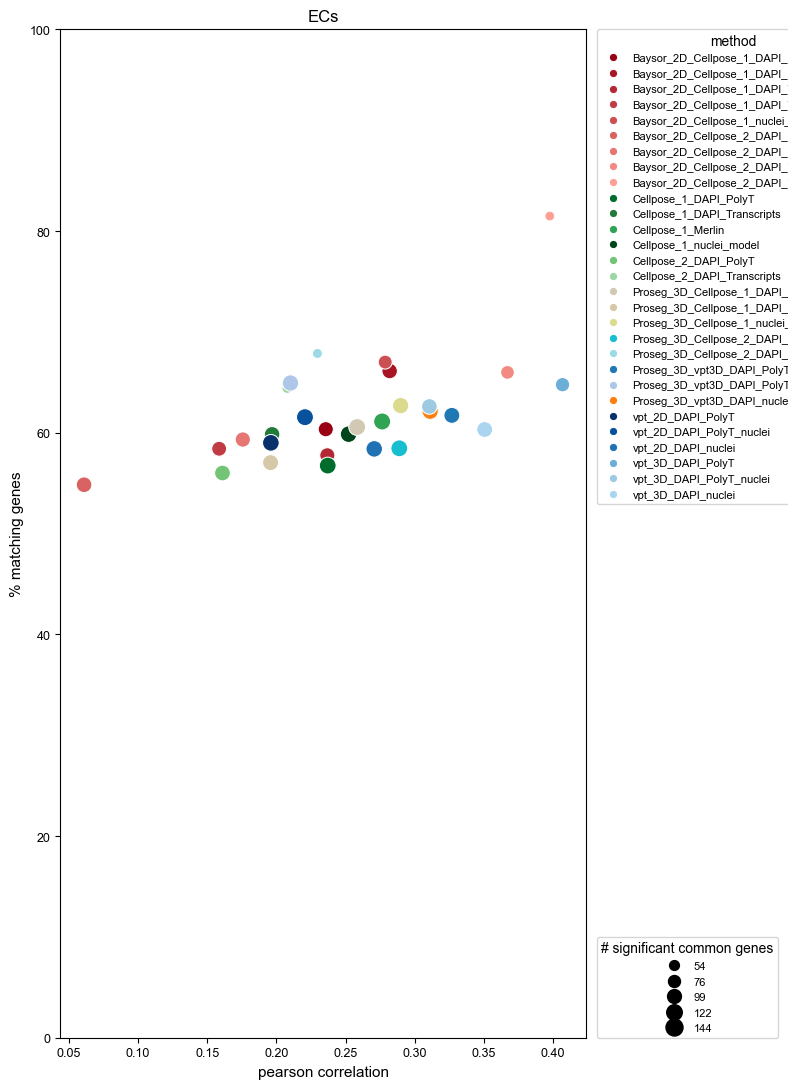

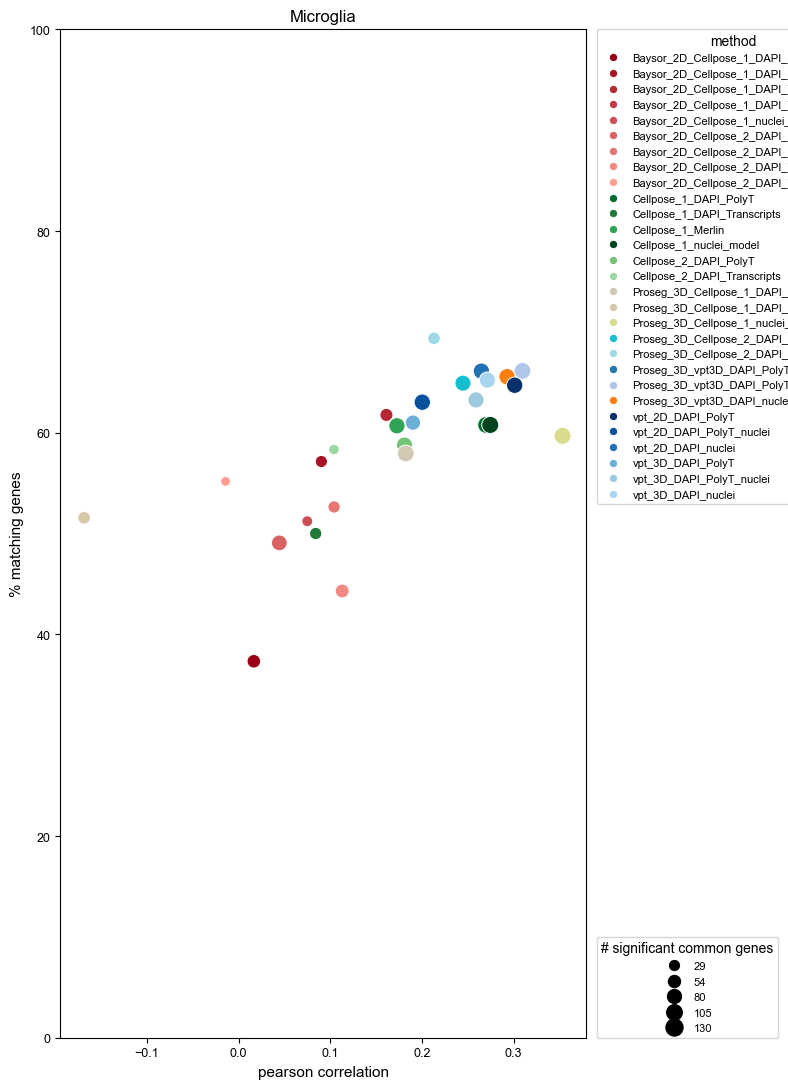

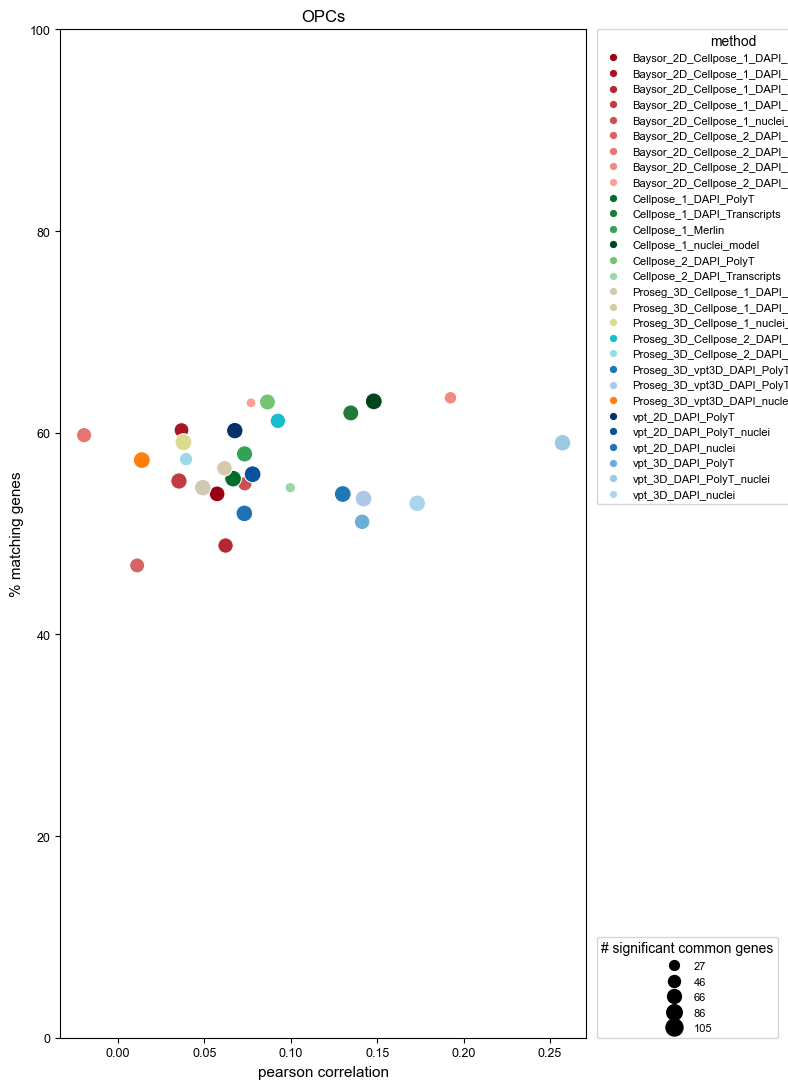

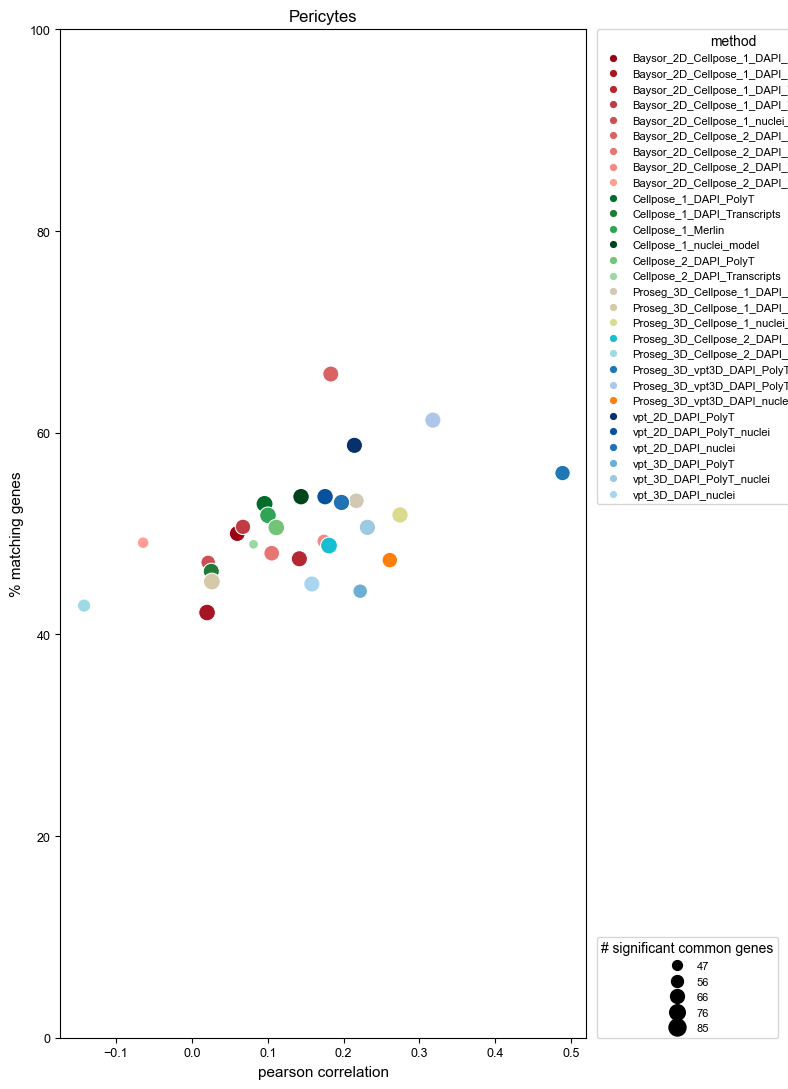

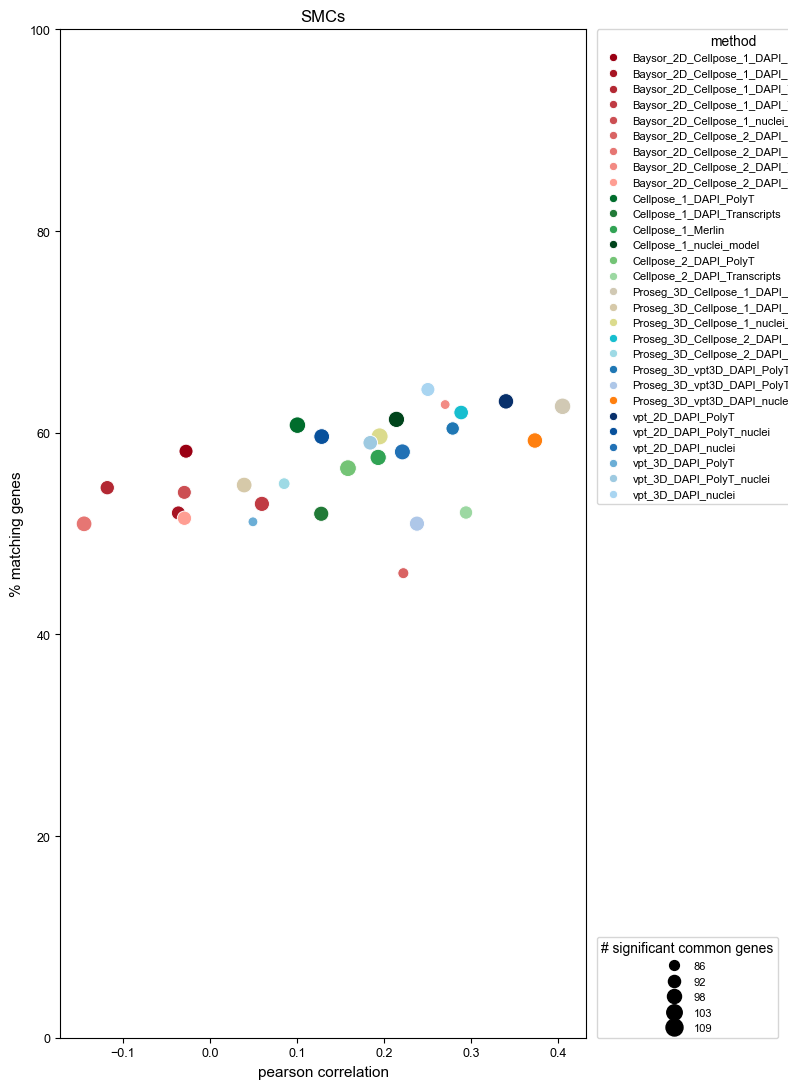

In [12]:
all_results = {}
for cell_type in cell_types_to_plot:
    res_df, fig, ax = plot_cell_type_results(cell_type)
    all_results[cell_type] = res_df
    plt.show()


In [10]:
for method in methods[:5]:
    dea_path = analysis_root / method / "dea" / dea_filename
    df = pd.read_excel(dea_path, sheet_name="ECs", nrows=2)
    print(method)
    print([c for c in df.columns if "p" in c.lower() or "fdr" in c.lower() or "adj" in c.lower()])
    print()

Baysor_2D_Cellpose_1_DAPI_PolyT_0.2
['PValue', 'FDR', 'test_group', 'subset_group', 'test_group_n']

Baysor_2D_Cellpose_1_DAPI_PolyT_0.8
['PValue', 'FDR', 'test_group', 'subset_group', 'test_group_n']

Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2
['PValue', 'FDR', 'test_group', 'subset_group', 'test_group_n']

Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8
['PValue', 'FDR', 'test_group', 'subset_group', 'test_group_n']

Baysor_2D_Cellpose_1_nuclei_model_1.0
['PValue', 'FDR', 'test_group', 'subset_group', 'test_group_n']

